# Metric Exploration
Training curves and ablation results for all PMG classification experiments.

Plot style replicates Guha & Bhandage (2025) — two-panel layout per model:
- **(a)** Training results: accuracy, loss, precision, recall on one axis
- **(b)** Validation results: same four metrics

```
results/metrics/          ← per-epoch train/val/test CSV per run
results/ablation_study/   ← per-checkpoint metrics on black-box occluded test images
```

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE          = Path("../results")
METRICS_DIR   = BASE / "metrics"
ABLATION_DIR  = BASE / "ablation_study"

# ── Paper colour scheme (matches Guha & Bhandage 2025 Figs 4–13) ─────────────
C = {
    "accuracy":  "#1f77b4",   # blue
    "loss":      "#d62728",   # red
    "precision": "#2ca02c",   # green
    "recall":    "#ff7f0e",   # orange
    "f1":        "#9467bd",   # purple
    "kappa":     "#8c564b",   # brown
}

plt.rcParams.update({
    "figure.dpi":      120,
    "font.size":       9,
    "axes.linewidth":  0.8,
    "lines.linewidth": 1.4,
})

## Load all training metrics

In [2]:
def _pretty_label(stem: str) -> str:
    """Turn a filename stem into a readable plot title."""
    stem = stem.replace("_metrics", "")
    parts = stem.split("_")          # e.g. ['resnet101','preprocessed','correct']
    model   = parts[0].upper().replace("RESNET", "ResNet-").replace("DENSENET", "DenseNet-")
    data    = parts[1].capitalize()  # Raw / Preprocessed
    mode    = " + ".join(p.capitalize() for p in parts[2:])
    return f"{model}  |  {data}  |  {mode}"

runs: dict[str, pd.DataFrame] = {}
for csv in sorted(METRICS_DIR.glob("*.csv")):
    label = _pretty_label(csv.stem)
    runs[label] = pd.read_csv(csv)

print(f"Loaded {len(runs)} runs:\n")
for k, df in runs.items():
    print(f"  {k:<60}  {len(df)} epochs")

Loaded 8 runs:

  DenseNet-201  |  Raw  |  Correct                              20 epochs
  DenseNet-201  |  Raw  |  Paper                                20 epochs
  ResNet-101  |  Preprocessed  |  Correct                       20 epochs
  ResNet-101  |  Preprocessed  |  Correct + Downsampled         20 epochs
  ResNet-101  |  Preprocessed  |  Paper                         20 epochs
  ResNet-101  |  Preprocessed  |  Paper + Downsampled           20 epochs
  ResNet-101  |  Raw  |  Correct                                20 epochs
  ResNet-101  |  Raw  |  Paper                                  20 epochs


## Training Curves — Paper Style
Each figure replicates the layout of Figs 4–13 in Guha & Bhandage (2025):
- **(a)** Training: accuracy, loss, precision, recall vs epoch
- **(b)** Validation: same four metrics

The red dashed line marks the **best-validation-loss epoch** (checkpoint saved).

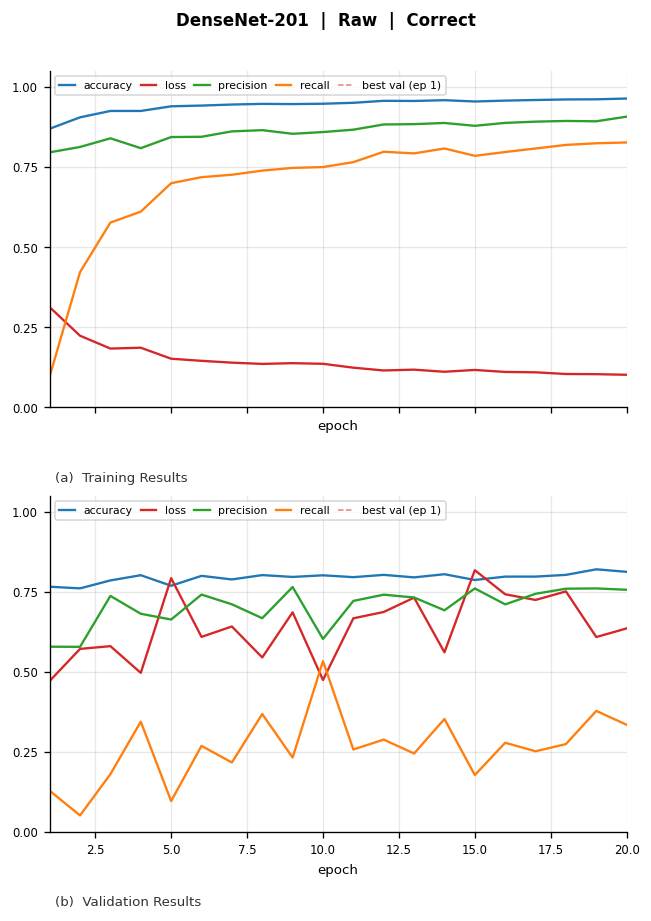

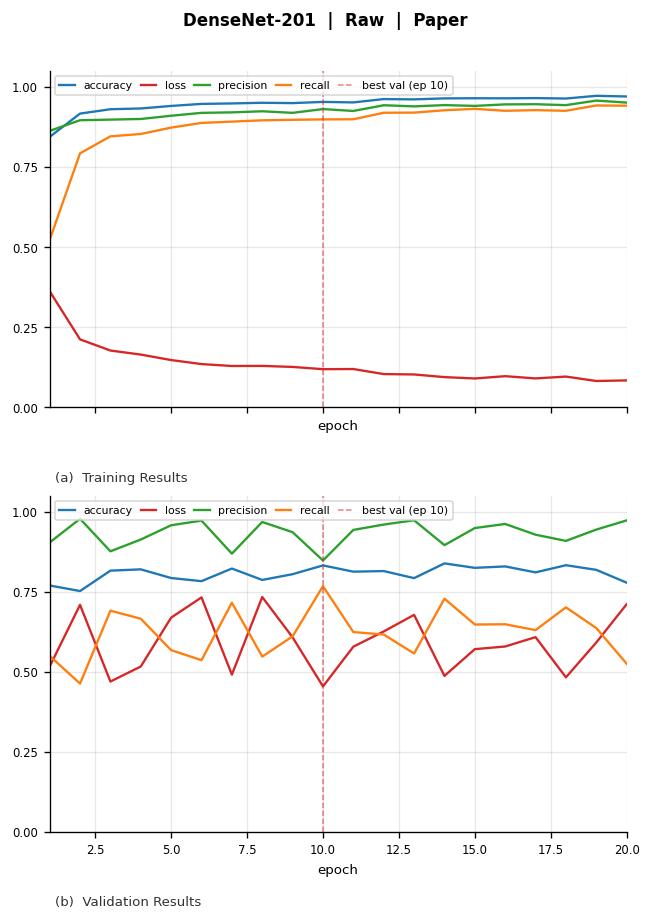

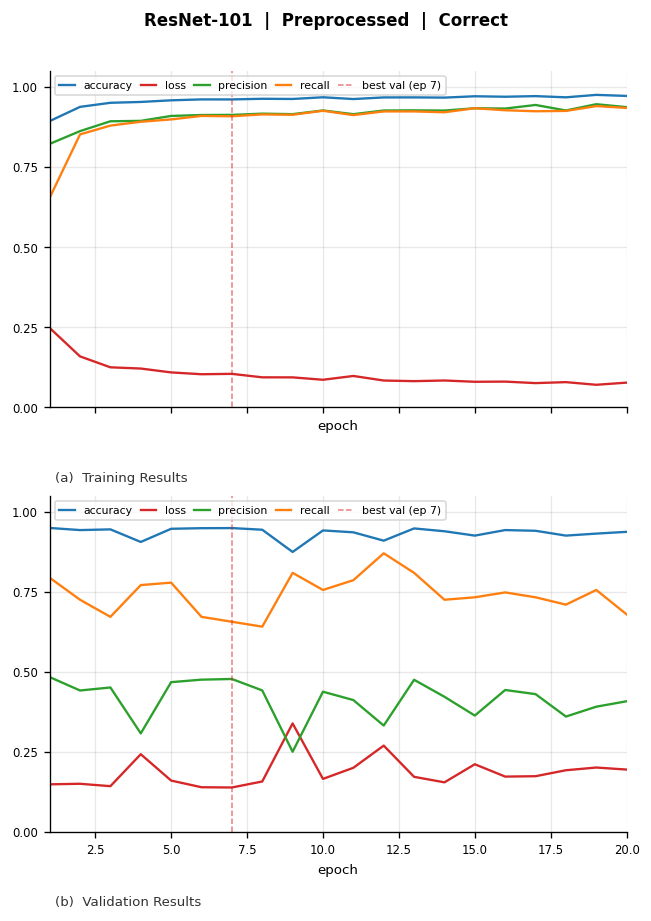

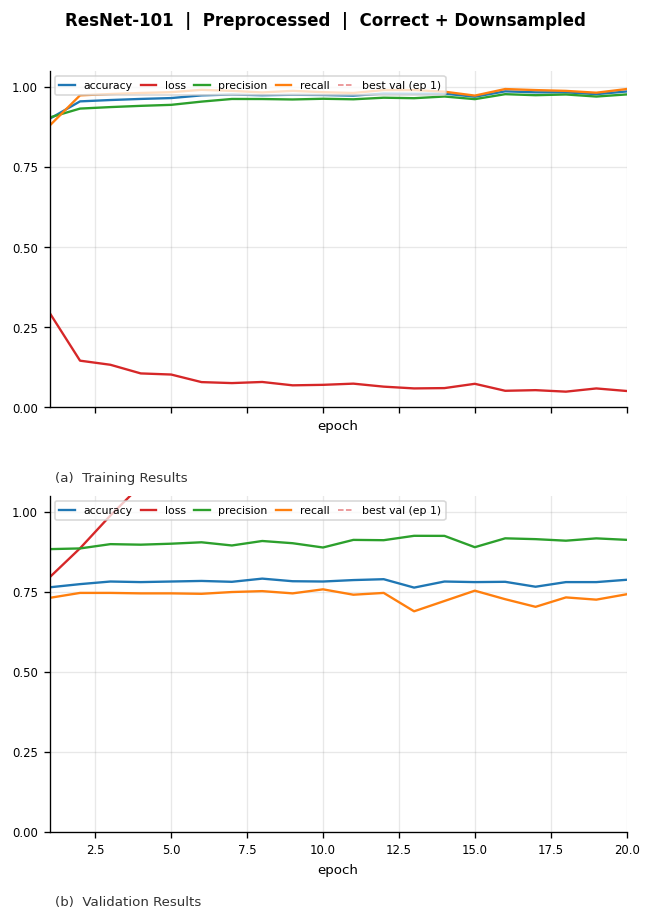

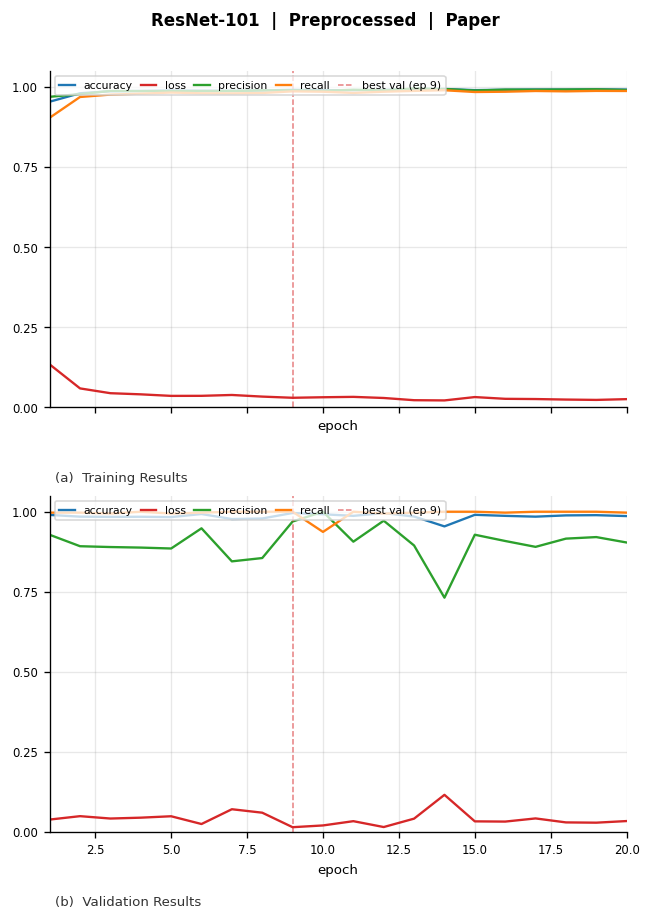

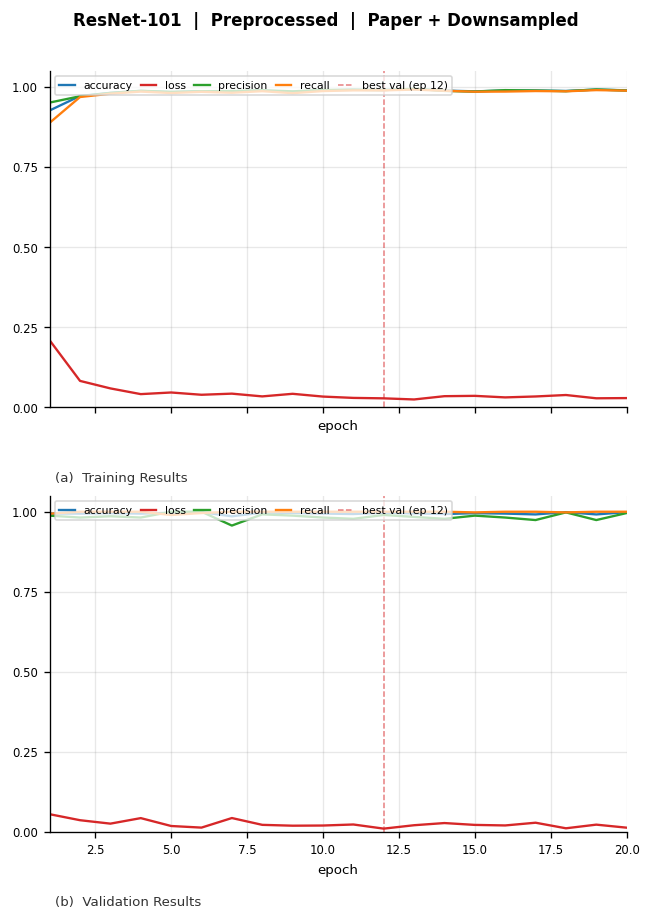

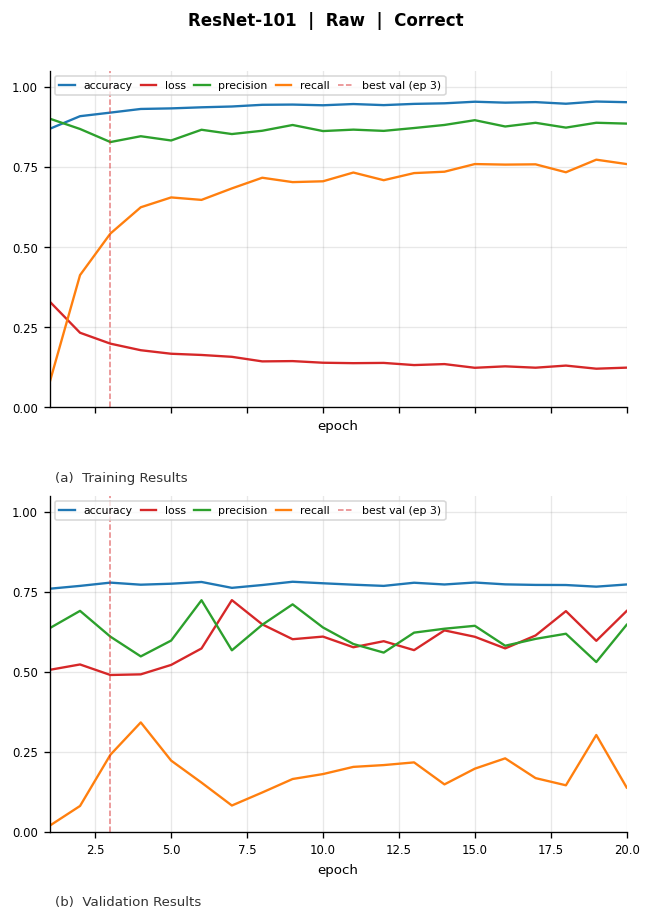

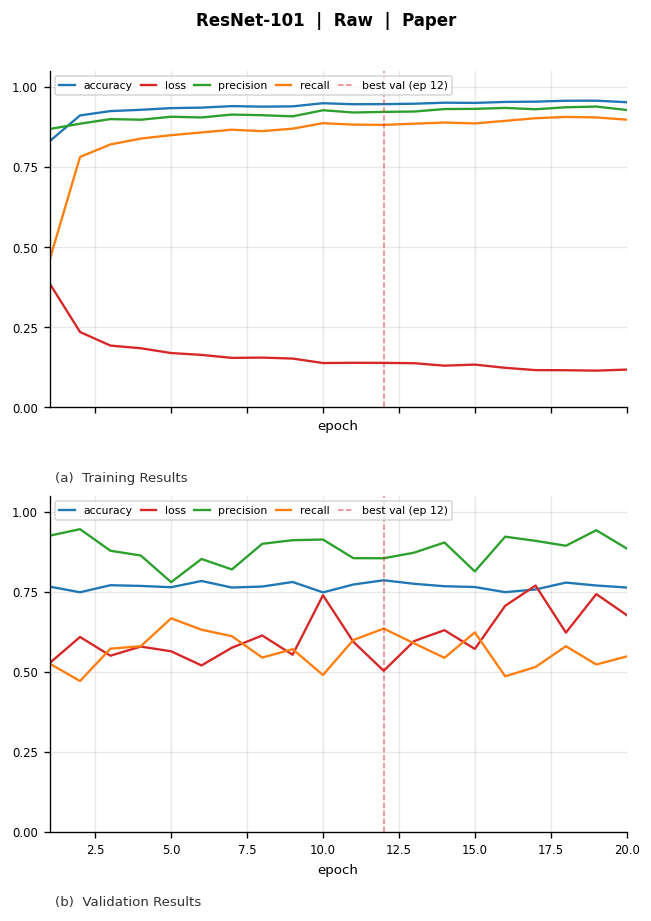

In [3]:
def plot_paper_style(df: pd.DataFrame, title: str, figsize=(5.5, 7.5)) -> None:
    """Two-panel plot replicating Guha & Bhandage (2025) Figs 4-13."""
    best_epoch = df.loc[df["val_loss"].idxmin(), "epoch"]

    fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True)
    fig.suptitle(title, fontsize=10, fontweight="bold", y=1.01)

    panels = [
        (axes[0], "train", "(a)  Training Results"),
        (axes[1], "val",   "(b)  Validation Results"),
    ]

    for ax, prefix, panel_label in panels:
        ax.plot(df["epoch"], df[f"{prefix}_acc"],       color=C["accuracy"],  label="accuracy")
        ax.plot(df["epoch"], df[f"{prefix}_loss"],      color=C["loss"],      label="loss")
        ax.plot(df["epoch"], df[f"{prefix}_precision"], color=C["precision"], label="precision")
        ax.plot(df["epoch"], df[f"{prefix}_recall"],    color=C["recall"],    label="recall")
        ax.axvline(best_epoch, color="#d62728", lw=0.9, ls="--", alpha=0.6, label=f"best val (ep {best_epoch})")

        ax.set_ylim(0, 1.05)
        ax.set_yticks([0, 0.25, 0.50, 0.75, 1.00])
        ax.set_xlim(df["epoch"].min(), df["epoch"].max())
        ax.set_xlabel("epoch", fontsize=8)
        ax.tick_params(labelsize=7)
        ax.grid(True, linestyle="-", alpha=0.18, color="grey")
        ax.spines[["top", "right"]].set_visible(False)
        ax.legend(fontsize=6.5, ncol=5, loc="upper left",
                  framealpha=0.75, handlelength=1.4, columnspacing=0.8)
        ax.text(0.01, -0.22, panel_label, transform=ax.transAxes,
                fontsize=8, ha="left", color="#333333")

    plt.tight_layout()
    plt.show()


for title, df in runs.items():
    plot_paper_style(df, title)

## Test Metrics at Best Checkpoint
For each run, test metrics are read at the **epoch with the lowest validation loss** — i.e. the epoch whose weights were saved as `_best.pt`.

In [15]:
# ── Collect best-epoch test metrics ───────────────────────────────────────────
records = []
for label, df in runs.items():
    best_idx = df["val_loss"].idxmin() 
    row = df.loc[best_idx]
    records.append({
        "run":        label,
        "epoch":      int(row["epoch"]),
        "test_acc":   row["test_acc"],
        "test_prec":  row["test_precision"],
        "test_rec":   row["test_recall"],
        "test_f1":    row["test_f1"],
        "test_kappa": row["test_kappa"],
    })

summary = pd.DataFrame(records).set_index("run")
display(summary.style
    .format({
        "epoch":      "{:.0f}",
        "test_acc":   "{:.3f}",
        "test_prec":  "{:.3f}",
        "test_rec":   "{:.3f}",
        "test_f1":    "{:.3f}",
        "test_kappa": "{:.3f}",
    })
    .background_gradient(cmap="YlGn", subset=["test_acc","test_prec","test_rec","test_f1","test_kappa"])
    .set_caption("Test metrics at best-val-loss epoch"))

,epoch,test_acc,test_prec,test_rec,test_f1,test_kappa
run,,,,,,
DenseNet-201 | Raw | Correct,1,0.870,0.466,0.146,0.222,0.171
DenseNet-201 | Raw | Paper,10,0.844,0.580,0.864,0.694,0.595
ResNet-101 | Preprocessed | Correct,7,0.932,0.532,0.906,0.670,0.635
ResNet-101 | Preprocessed | Correct + Downsampled,1,0.913,0.876,0.917,0.896,0.821
ResNet-101 | Preprocessed | Paper,9,0.999,1.000,0.997,0.999,0.998
ResNet-101 | Preprocessed | Paper + Downsampled,12,0.982,0.982,0.993,0.987,0.958
ResNet-101 | Raw | Correct,3,0.892,0.599,0.472,0.528,0.468
ResNet-101 | Raw | Paper,12,0.878,0.676,0.774,0.722,0.644


In [ ]:
# ── Horizontal grouped bar chart — all runs × 4 key metrics ───────────────────
metrics_to_plot = [("test_acc",  "Accuracy",  C["accuracy"]),
                   ("test_prec", "Precision", C["precision"]),
                   ("test_rec",  "Recall",    C["recall"]),
                   ("test_f1",   "F1 Score",  C["f1"])]

short_labels = [r.split("|")[0].strip() + "  |" + "|".join(r.split("|")[1:]).strip()
                for r in summary.index]

n      = len(summary)
y      = np.arange(n)
height = 0.18

fig, ax = plt.subplots(figsize=(10, max(5, n * 0.6)))

for i, (col, lbl, color) in enumerate(metrics_to_plot):
    offsets = y + (i - 1.5) * height
    bars = ax.barh(offsets, summary[col], height, label=lbl,
                   color=color, alpha=0.85, edgecolor="white", linewidth=0.4)
    for bar in bars:
        w = bar.get_width()
        ax.text(w + 0.004, bar.get_y() + bar.get_height() / 2,
                f"{w:.2f}", va="center", fontsize=6)

ax.set_yticks(y)
ax.set_yticklabels(short_labels, fontsize=7)
ax.set_xlim(0, 1.12)
ax.set_xlabel("Score")
ax.set_title("Test Metrics at Best-Val-Loss Checkpoint", fontweight="bold")
ax.legend(fontsize=8, loc="lower right")
ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Ablation Study — Black-Box Occlusion
Each checkpoint is evaluated on the **test set with a random 20% black-box occlusion** applied to every image.
This tests whether the model learned meaningful brain features or exploited trivial image-level statistics (FOV, resolution).

A model that learned genuine pathological features should drop less on occluded data than one exploiting image-level artefacts.

In [6]:
df_abl = pd.read_csv(ABLATION_DIR / "ablation_results.csv")

# ── Parse checkpoint name into structured columns ─────────────────────────────
def parse_ckpt(name: str) -> dict:
    n = name.replace(".pt", "").replace(".pth", "")
    parts = n.split("_")
    model = parts[0]                           # resnet101 / densenet201
    data  = parts[1]                           # raw / preprocessed
    ckpt  = parts[2]                           # best / final
    mode  = "_".join(parts[3:]) if len(parts) > 3 else ""
    return {"model": model, "data": data, "ckpt_type": ckpt, "mode": mode}

meta = df_abl["checkpoint"].apply(parse_ckpt).apply(pd.Series)
df_abl = pd.concat([df_abl, meta], axis=1)
df_abl["short_label"] = (df_abl["model"] + "\n"
                         + df_abl["data"] + "  "
                         + df_abl["ckpt_type"] + "  "
                         + df_abl["mode"])
df_abl.set_index("checkpoint", inplace=True)
display(df_abl[["accuracy","precision","recall","f1_score"]]
    .style
    .format("{:.3f}")
    .background_gradient(cmap="YlGn")
    .set_caption("Ablation: metrics on black-box occluded test images"))

,accuracy,precision,recall,f1_score
checkpoint,,,,
densenet201_raw_best_correct.pt,0.871,0.759,0.871,0.811
densenet201_raw_best_paper.pt,0.664,0.829,0.664,0.718
densenet201_raw_final_correct.pt,0.876,0.847,0.876,0.837
densenet201_raw_final_paper.pt,0.843,0.830,0.843,0.836
resnet101_preprocessed_best_correct.pt,0.961,0.961,0.961,0.958
resnet101_preprocessed_best_correct_downsampled.pt,0.940,0.944,0.940,0.942
resnet101_preprocessed_best_paper.pt,0.917,0.948,0.917,0.925
resnet101_preprocessed_best_paper_downsampled.pt,0.881,0.934,0.881,0.895
resnet101_preprocessed_final_correct.pt,0.980,0.980,0.980,0.980


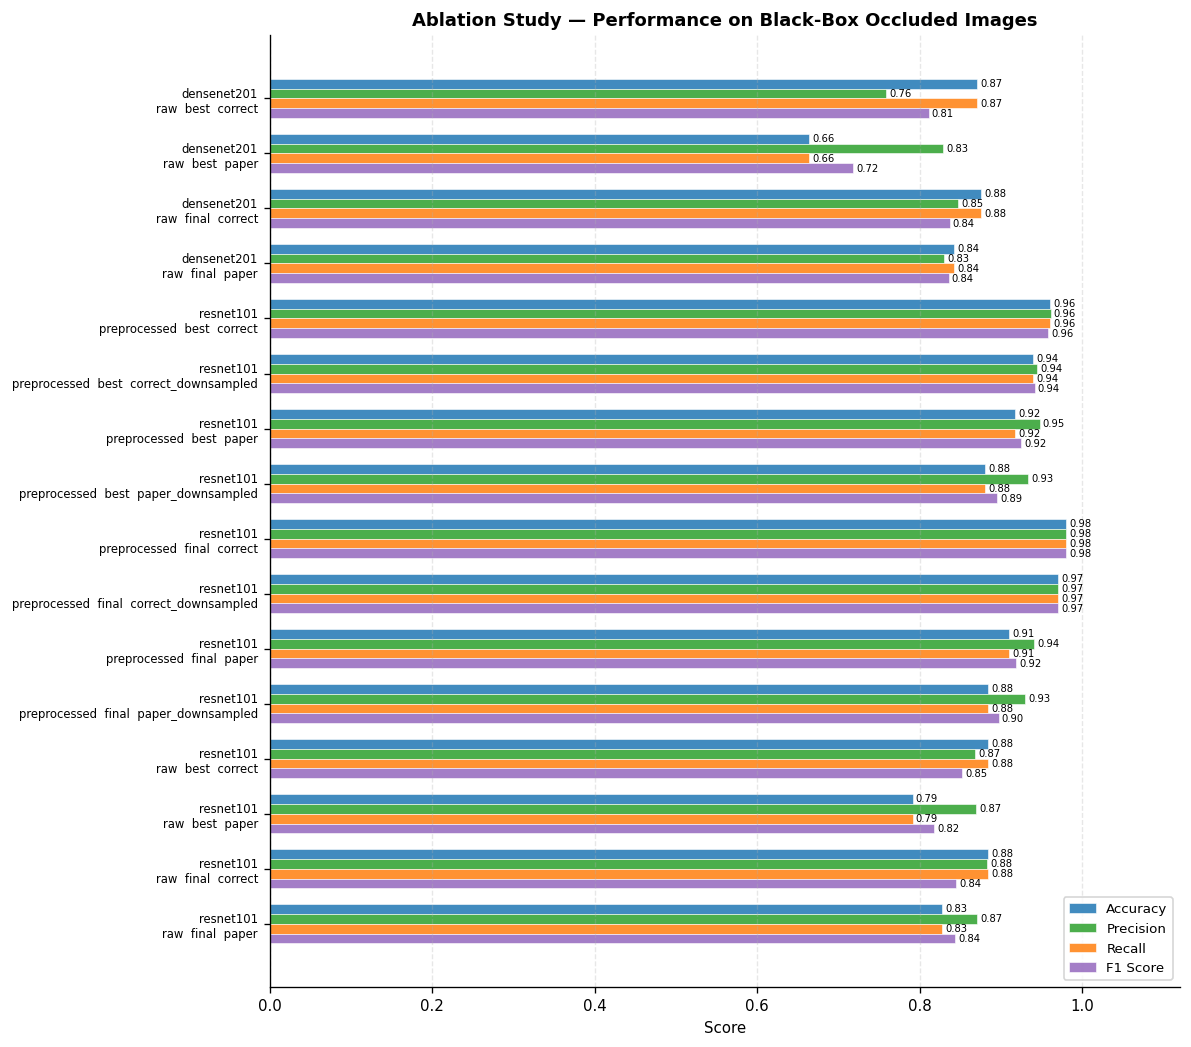

In [7]:
# ── Horizontal grouped bar chart ───────────────────────────────────────────────
abl_metrics = [("accuracy",  "Accuracy",  C["accuracy"]),
               ("precision", "Precision", C["precision"]),
               ("recall",    "Recall",    C["recall"]),
               ("f1_score",  "F1 Score",  C["f1"])]

n      = len(df_abl)
y      = np.arange(n)
height = 0.18

fig, ax = plt.subplots(figsize=(10, max(6, n * 0.55)))

for i, (col, lbl, color) in enumerate(abl_metrics):
    offsets = y + (i - 1.5) * height
    bars = ax.barh(offsets, df_abl[col], height,
                   label=lbl, color=color, alpha=0.85,
                   edgecolor="white", linewidth=0.4)
    for bar in bars:
        w = bar.get_width()
        ax.text(w + 0.004, bar.get_y() + bar.get_height() / 2,
                f"{w:.2f}", va="center", fontsize=6)

ax.set_yticks(y)
ax.set_yticklabels(df_abl["short_label"].values, fontsize=7)
ax.set_xlim(0, 1.12)
ax.set_xlabel("Score")
ax.set_title("Ablation Study — Performance on Black-Box Occluded Images",
             fontweight="bold")
ax.legend(fontsize=8, loc="lower right")
ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Ablation Analysis — Raw vs Preprocessed
Compare the drop in performance between clean (training metrics) and occluded (ablation) test images per model.

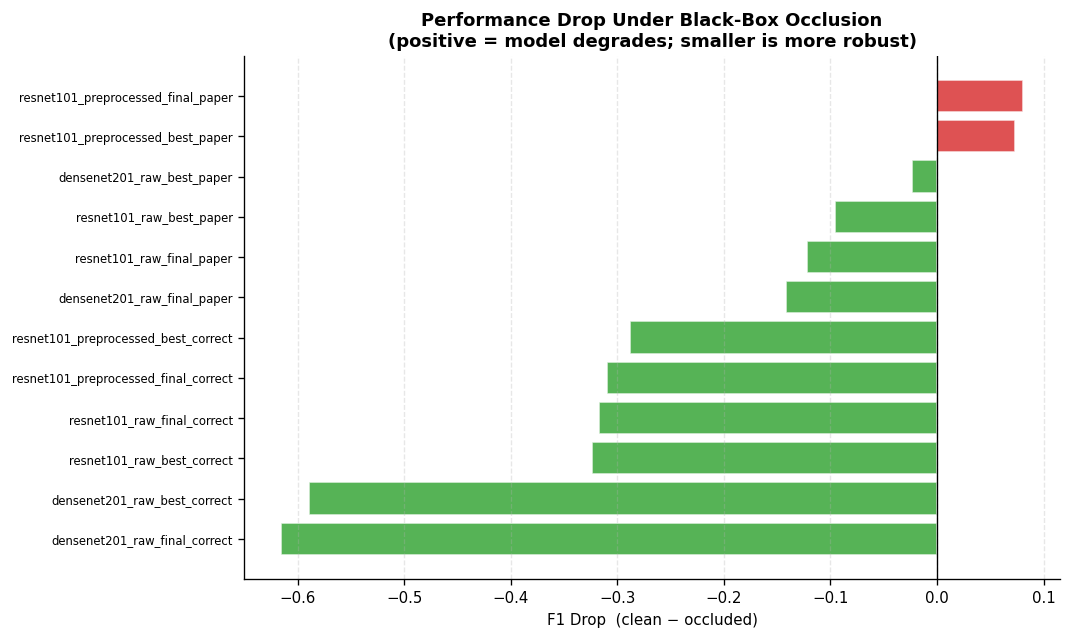

In [ ]:
drop_records = []
for ckpt_name, abl_row in df_abl.iterrows():
    model     = abl_row["model"]
    data      = abl_row["data"]
    mode      = abl_row["mode"]
    ckpt_type = abl_row["ckpt_type"]

    # Find matching training run
    run_key = None
    for k in summary.index:
        k_lower = k.lower().replace(" ", "").replace("-", "")
        if model.replace("101","101").replace("201","201") in k_lower and data in k_lower and mode in k_lower:
            run_key = k
            break

    if run_key is None:
        continue

    clean_f1 = summary.loc[run_key, "test_f1"]
    occl_f1  = abl_row["f1_score"]
    drop_records.append({
        "checkpoint": ckpt_name,
        "model":      model,
        "data":       data,
        "mode":       mode,
        "clean_f1":   clean_f1,
        "occluded_f1": occl_f1,
        "drop":       clean_f1 - occl_f1,
    })

if drop_records:
    df_drop = pd.DataFrame(drop_records).sort_values("drop", ascending=True)

    fig, ax = plt.subplots(figsize=(9, max(4, len(df_drop) * 0.45)))
    colors  = ["#d62728" if d > 0 else "#2ca02c" for d in df_drop["drop"]]
    ax.barh(range(len(df_drop)), df_drop["drop"], color=colors, alpha=0.8, edgecolor="white")
    ax.set_yticks(range(len(df_drop)))
    ax.set_yticklabels(df_drop["checkpoint"].str.replace(".pt",""), fontsize=7)
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlabel("F1 Drop  (clean − occluded)")
    ax.set_title("Performance Drop Under Black-Box Occlusion\n(positive = model degrades; smaller is more robust)",
                 fontweight="bold")
    ax.grid(axis="x", linestyle="--", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()
else:
    print("No matching training runs found for drop analysis — run training CSVs must share model+data+mode with ablation checkpoints.")


> **Guha & Bhandage (2025)** addressed this by downsampling the HC class to match the PMG count (4,517 per class). The `balance_mode=pre_split` runs in this project replicate that approach; `post_split` is the methodologically correct alternative.